# Realistic Universal Hybrid Control in Dispersive cQED

This notebook reproduces the synthesis study that asks whether the ideal primitive universal-control claim for a transmon-cavity system survives the realistic dispersive Hamiltonian once `chi`, `chi'`, Kerr, and finite pulse durations are enforced.

## Environment Setup

The notebook only loads saved results by default. It can optionally rerun the synthesis builder script, which itself aggregates validated repository artifacts rather than rerunning every upstream study.

In [1]:
from pathlib import Path
import json
import subprocess
import matplotlib.pyplot as plt
from matplotlib.image import imread

study_root = Path(r'C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\realistic_universal_hybrid_control_dispersive_cqed')
data_dir = Path(r'C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\realistic_universal_hybrid_control_dispersive_cqed\data')
figures_dir = Path(r'C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\realistic_universal_hybrid_control_dispersive_cqed\figures')
print('Study root:', study_root)
print('Data dir:', data_dir)
print('Figures dir:', figures_dir)

Study root: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\realistic_universal_hybrid_control_dispersive_cqed
Data dir: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\realistic_universal_hybrid_control_dispersive_cqed\data
Figures dir: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\realistic_universal_hybrid_control_dispersive_cqed\figures


## User-Tunable Parameters

All user-facing knobs are collected here. The default workflow loads saved artifacts, but you can flip `rerun_builder` to regenerate the synthesis summary and figures.

In [2]:
rerun_builder = False
show_phase_budget = True
show_timescale_hierarchy = True
max_rows_to_print = 7

print('rerun_builder =', rerun_builder)
print('show_phase_budget =', show_phase_budget)
print('show_timescale_hierarchy =', show_timescale_hierarchy)
print('max_rows_to_print =', max_rows_to_print)

rerun_builder = False
show_phase_budget = True
show_timescale_hierarchy = True
max_rows_to_print = 7


## Derived Objects

This cell derives the saved-file paths from the tunable parameters so that rerunning Sections 3 and 4 is enough to propagate any parameter change.

In [3]:
summary_path = data_dir / 'synthesis_summary.json'
timescale_png = figures_dir / 'timescale_hierarchy.png'
phase_budget_png = figures_dir / 'phase_budget.png'
builder_script = study_root / 'scripts' / 'build_synthesis_dataset.py'
summary_path, timescale_png, phase_budget_png, builder_script

(WindowsPath('C:/Users/jl82323/Box/Shyam Shankar Quantum Circuits Group/Users/Users_JianJun/cqed_based_study/studies/realistic_universal_hybrid_control_dispersive_cqed/data/synthesis_summary.json'),
 WindowsPath('C:/Users/jl82323/Box/Shyam Shankar Quantum Circuits Group/Users/Users_JianJun/cqed_based_study/studies/realistic_universal_hybrid_control_dispersive_cqed/figures/timescale_hierarchy.png'),
 WindowsPath('C:/Users/jl82323/Box/Shyam Shankar Quantum Circuits Group/Users/Users_JianJun/cqed_based_study/studies/realistic_universal_hybrid_control_dispersive_cqed/figures/phase_budget.png'),
 WindowsPath('C:/Users/jl82323/Box/Shyam Shankar Quantum Circuits Group/Users/Users_JianJun/cqed_based_study/studies/realistic_universal_hybrid_control_dispersive_cqed/scripts/build_synthesis_dataset.py'))

## Step-by-Step Reproduction

The default path is to load the saved synthesis outputs. A commented rerun cell is included immediately after it.

In [4]:
# --- Load saved results (default) ---
summary = json.loads(summary_path.read_text(encoding='utf-8'))
summary['top_level_verdict']

{'strict_ideal_gate_set_survives': False,
 'non_grape_structured_universal_control_demonstrated': False,
 'practical_phase_aware_route_supported': True,
 'practical_phase_aware_route_text': 'A realistic constructive route is supported only after replacing strict ideal SQR by phase-aware selective control: short branch-compensated displacement, short spectator-limited qubit rotations, relaxed CPSQR / cphase-SQR, and a cleanup layer such as SNAP or virtual-Z correction. Even then, a fully pulse-backed universal architecture is not yet demonstrated.',
 'most_defensible_scientific_statement': 'The abstract universal-control claim does not survive literally once chi, chi-prime, Kerr, and finite-pulse phase accumulation are enforced. What survives is a weaker, phase-aware control library whose strongest successes are low-dimensional, gauge-relaxed, and still short of a fully validated non-GRAPE universal stack.'}

In [5]:
# --- Re-run with current parameters ---
# if rerun_builder:
#     subprocess.run(['python', str(builder_script)], check=True)
#     summary = json.loads(summary_path.read_text(encoding='utf-8'))
# summary['top_level_verdict']

## Primitive Verdict Table

The table below reproduces the unified primitive-level verdicts used in the report.

In [6]:
rows = summary['primitive_verdicts'][:max_rows_to_print]
for row in rows:
    print(row['primitive'])
    print('  family   :', row['best_structured_family'])
    print('  metric   :', row['best_metric_label'], row['best_metric_value'])
    print('  chiT/2pi :', row['chi_t_over_2pi'])
    print('  verdict  :', row['verdict'])
    print('  obstacle :', row['main_obstruction'])
    print()

Unconditional cavity displacement
  family   : Two-tone branch-compensated displacement
  metric   : Broad-state mean fidelity 0.9857
  chiT/2pi : 0.056799999999999996
  verdict  : Approximate success on short calibrated pulses
  obstacle : Branch detuning from chi and finite-pulse phase accumulation; naive echo fails once the inserted pi pulse becomes manifold dependent.

Unconditional qubit rotation
  family   : Short Gaussian/DRAG vacuum-calibrated pulse
  metric   : Vacuum X_pi fidelity 0.999841
  chiT/2pi : 0.11359999999999999
  verdict  : Only spectator-limited, not truly unconditional
  obstacle : Photon-number-dependent qubit detuning through chi and chi-prime turns the pulse into a Fock-selective operation as cavity occupation grows.

Selective qubit rotation (relaxed CPSQR / cphase-SQR)
  family   : Short flat-top Gaussian cphase-SQR
  metric   : Noisy relaxed fidelity 0.9902786522509661
  chiT/2pi : 1.0
  verdict  : Robust practical primitive
  obstacle : Strict logical gaug

## Validation

This section reproduces the study's key consistency checks: the derived timing hierarchy and the phase-budget trends.

In [7]:
summary['derived_timescales']

{'inverse_abs_chi_over_2pi_ns': 352.11267605633805,
 'fast_two_tone_displacement_chi_t_over_2pi': 0.056799999999999996,
 'best_noisy_sqr_chi_t_over_2pi': 1.0,
 'best_snap_pi_chi_t_over_2pi': 2.2,
 'strict_sqr_threshold_chi_t_over_2pi': 3.0}

In [8]:
phase_rows = summary['phase_budget_rows'][:12]
phase_rows

[{'label': 'fast_displacement',
  'duration_ns': 20.0,
  'fock_n': 0,
  'qubit_branch_phase_cycles': 0.0,
  'cavity_kerr_phase_cycles': 0.0},
 {'label': 'fast_displacement',
  'duration_ns': 20.0,
  'fock_n': 1,
  'qubit_branch_phase_cycles': 0.056799999999999996,
  'cavity_kerr_phase_cycles': 0.0},
 {'label': 'fast_displacement',
  'duration_ns': 20.0,
  'fock_n': 2,
  'qubit_branch_phase_cycles': 0.11444,
  'cavity_kerr_phase_cycles': 0.0011200000000000001},
 {'label': 'fast_displacement',
  'duration_ns': 20.0,
  'fock_n': 3,
  'qubit_branch_phase_cycles': 0.17292,
  'cavity_kerr_phase_cycles': 0.0033600000000000006},
 {'label': 'fast_displacement',
  'duration_ns': 20.0,
  'fock_n': 4,
  'qubit_branch_phase_cycles': 0.23224,
  'cavity_kerr_phase_cycles': 0.006720000000000001},
 {'label': 'fast_displacement',
  'duration_ns': 20.0,
  'fock_n': 5,
  'qubit_branch_phase_cycles': 0.2924,
  'cavity_kerr_phase_cycles': 0.011200000000000002},
 {'label': 'vacuum_pi_rotation',
  'duration_n

## Key Figures

These are the report figures generated by the synthesis script.

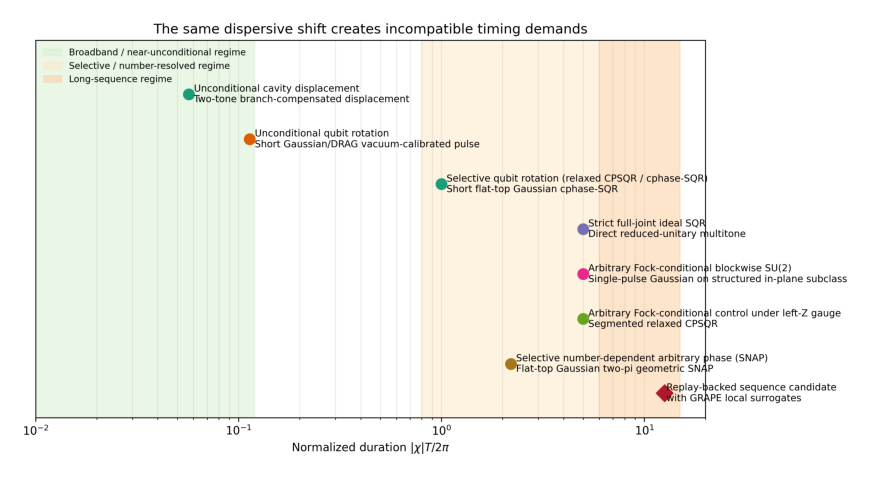

In [9]:
if show_timescale_hierarchy:
    img = imread(timescale_png)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

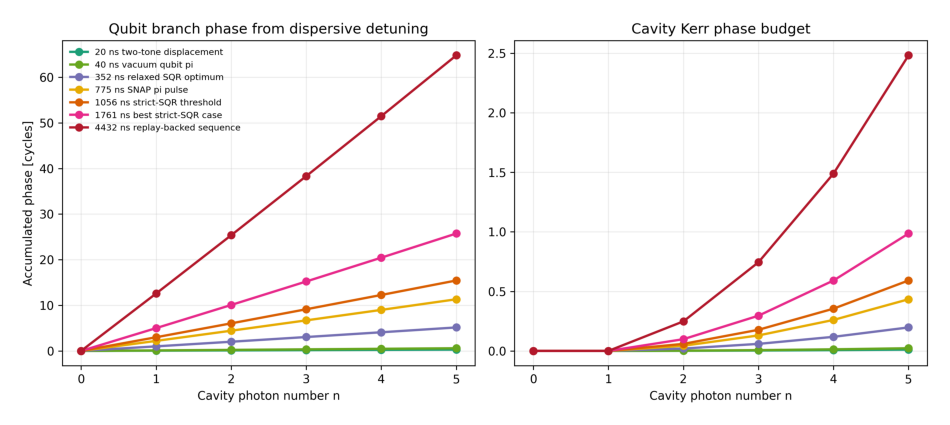

In [10]:
if show_phase_budget:
    img = imread(phase_budget_png)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

## Summary

The saved outputs support a clear conclusion: the strict ideal primitive gate set does not survive the realistic dispersive Hamiltonian as a literal statement. A weaker phase-aware constructive library does survive, but it is low-dimensional, gauge-relaxed, and not yet a fully demonstrated non-GRAPE universal stack.

| Tunable parameter | Default value | Effect |
|---|---:|---|
| `rerun_builder` | `False` | Regenerates the unified summary and figures from the aggregation script. |
| `show_phase_budget` | `True` | Displays the phase-budget figure. |
| `show_timescale_hierarchy` | `True` | Displays the timing-hierarchy figure. |
| `max_rows_to_print` | `7` | Limits how many primitive verdict rows are printed in the notebook. |